# Gradient Boosting

## Overview
Gradient Boosting builds an ensemble of **weak learners (shallow trees) sequentially**, where each new tree corrects the **residual errors** of the previous ensemble. Unlike Random Forest (which builds trees in parallel and averages), Gradient Boosting builds trees **one at a time**, each focused on the mistakes of the combined model so far.

### Core Algorithm:
1. Start with an initial prediction $F_0(x)$ (usually the mean of $y$)
2. For $m = 1, 2, ..., M$:
   - Compute **pseudo-residuals**: $r_i = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}$
   - Fit a weak tree $h_m(x)$ to the residuals
   - Update: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$
3. Final prediction: $F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} h_m(x)$

### Key Hyperparameters:
| Parameter | Role |
|-----------|------|
| `n_estimators` | Number of boosting rounds (trees) |
| `learning_rate` ($\eta$) | Shrinkage — how much each tree contributes |
| `max_depth` | Depth of each weak tree (usually 3–5) |
| `subsample` | Fraction of samples used per tree (stochastic GB) |
| `min_samples_leaf` | Minimum samples in a leaf |

### Tradeoff:
$$\text{Small } \eta + \text{Large } M \quad \Leftrightarrow \quad \text{Large } \eta + \text{Small } M$$
Smaller learning rate generally generalizes better but requires more trees.

---
### Topics Covered
1. Residual fitting intuition
2. Classification with GradientBoostingClassifier
3. Effect of n_estimators and learning_rate
4. Staged predictions — watching the model improve
5. Feature importance
6. Partial Dependence Plots (PDP)
7. Regression with GradientBoostingRegressor
8. Stochastic Gradient Boosting (subsample)
9. GridSearchCV tuning
10. Real-world offline-safe dataset
11. Full comparison: DT vs RF vs GB


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.datasets import make_classification, make_regression

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'gb':        '#F39C12',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Residual Fitting Intuition

Each new tree in Gradient Boosting is fit to the **residuals** (errors) of the current model — not the original targets.

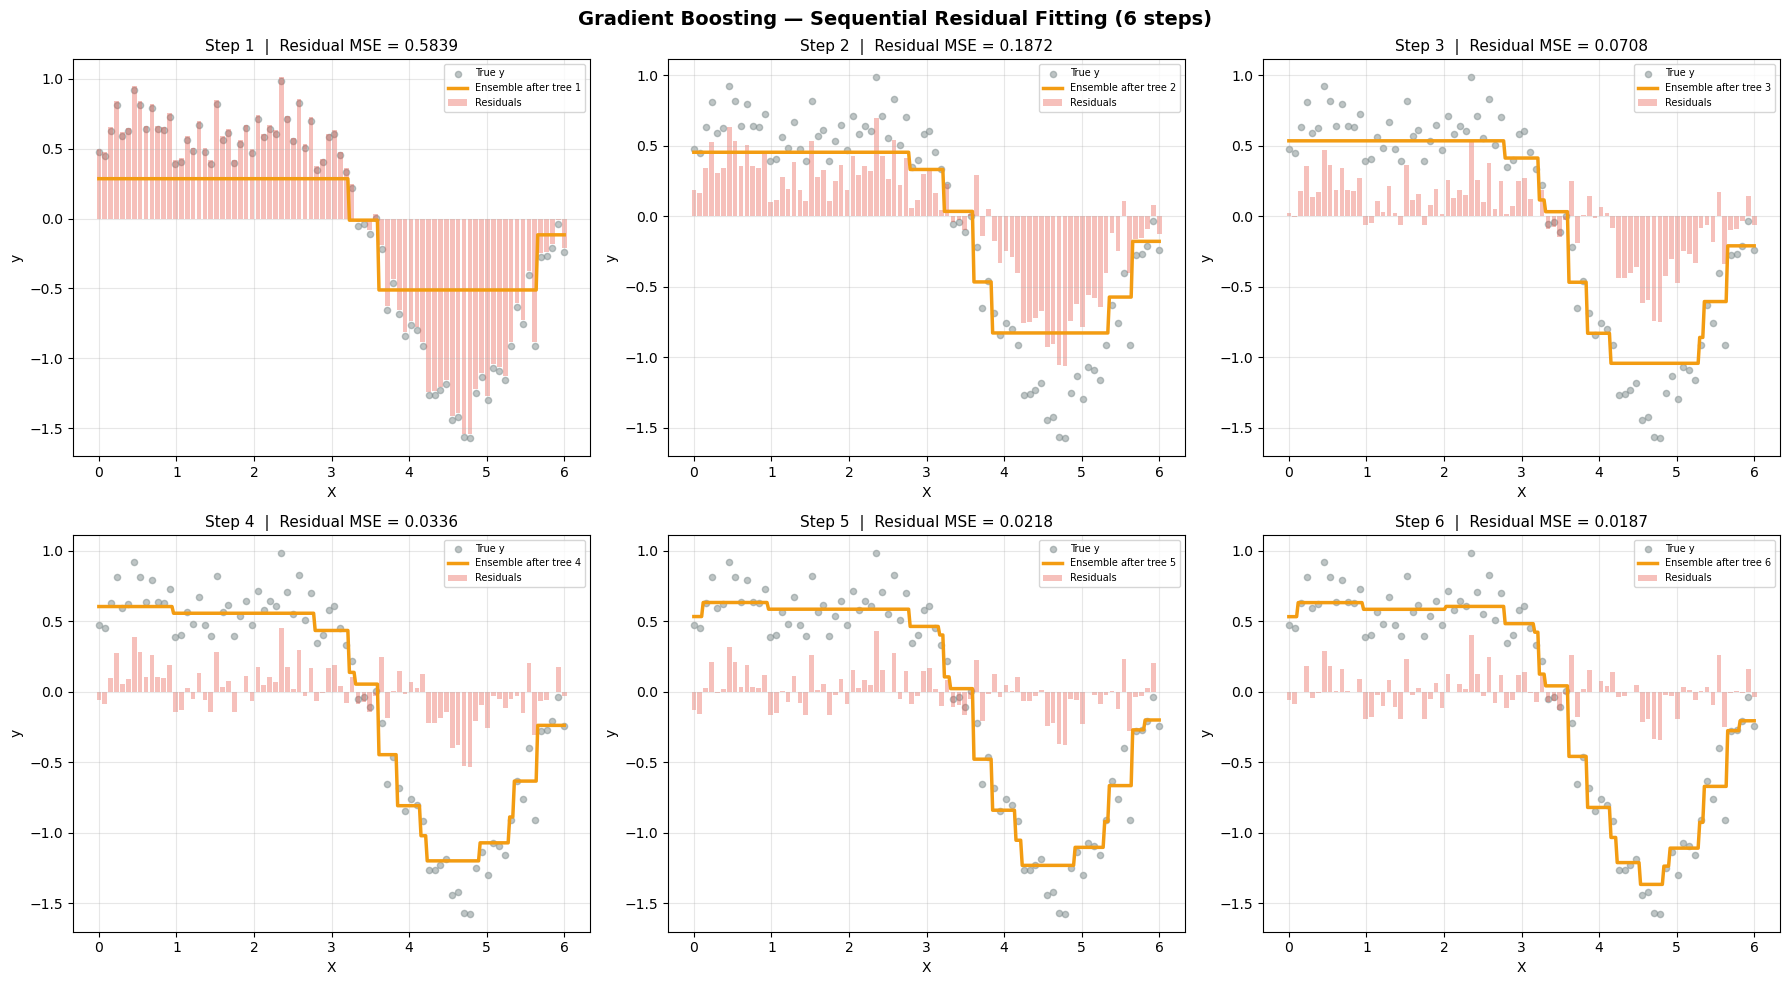

Each step: fit a new tree to residuals -> update ensemble -> residuals shrink.


In [2]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_toy = np.linspace(0, 6, 80).reshape(-1, 1)
y_toy = np.sin(X_toy).ravel() + 0.4*np.cos(2*X_toy).ravel() + np.random.randn(80)*0.15

learning_rate = 0.5
F = np.full(len(y_toy), y_toy.mean())   # F0 = mean
X_plot = np.linspace(0, 6, 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

F_plot = np.full(300, y_toy.mean())

for step in range(6):
    residuals = y_toy - F
    tree_s = DecisionTreeRegressor(max_depth=2, random_state=step)
    tree_s.fit(X_toy, residuals)
    update      = learning_rate * tree_s.predict(X_toy)
    update_plot = learning_rate * tree_s.predict(X_plot)
    F       += update
    F_plot  += update_plot

    ax = axes[step]
    ax.scatter(X_toy, y_toy, s=20, alpha=0.5, color=COLORS['neutral'], label='True y')
    ax.plot(X_plot, F_plot, color=COLORS['gb'], linewidth=2.5,
            label=f'Ensemble after tree {step+1}')
    ax.bar(X_toy.ravel(), residuals, width=0.06, alpha=0.35,
           color=COLORS['danger'], label='Residuals')
    residual_mse = np.mean(residuals**2)
    ax.set_title(f'Step {step+1}  |  Residual MSE = {residual_mse:.4f}', fontsize=11)
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=7)

plt.suptitle('Gradient Boosting — Sequential Residual Fitting (6 steps)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each step: fit a new tree to residuals -> update ensemble -> residuals shrink.')

## 3. Classification — Generate Dataset & Fit GB

n_estimators  : 100
learning_rate : 0.1
max_depth     : 3
Test Accuracy : 0.8833
Test ROC-AUC  : 0.9681


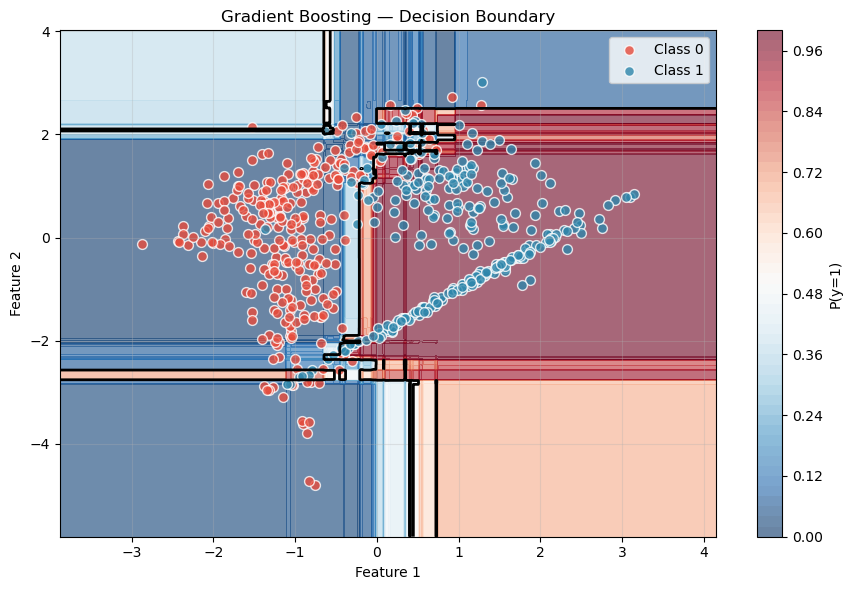

In [3]:
np.random.seed(42)
X, y = make_classification(
    n_samples=600, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=3, random_state=42
)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

print(f'n_estimators  : {gb.n_estimators}')
print(f'learning_rate : {gb.learning_rate}')
print(f'max_depth     : {gb.max_depth}')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')

# Decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = gb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
            edgecolors='white', s=50, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
            edgecolors='white', s=50, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Gradient Boosting — Decision Boundary')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Effect of n_estimators and learning_rate

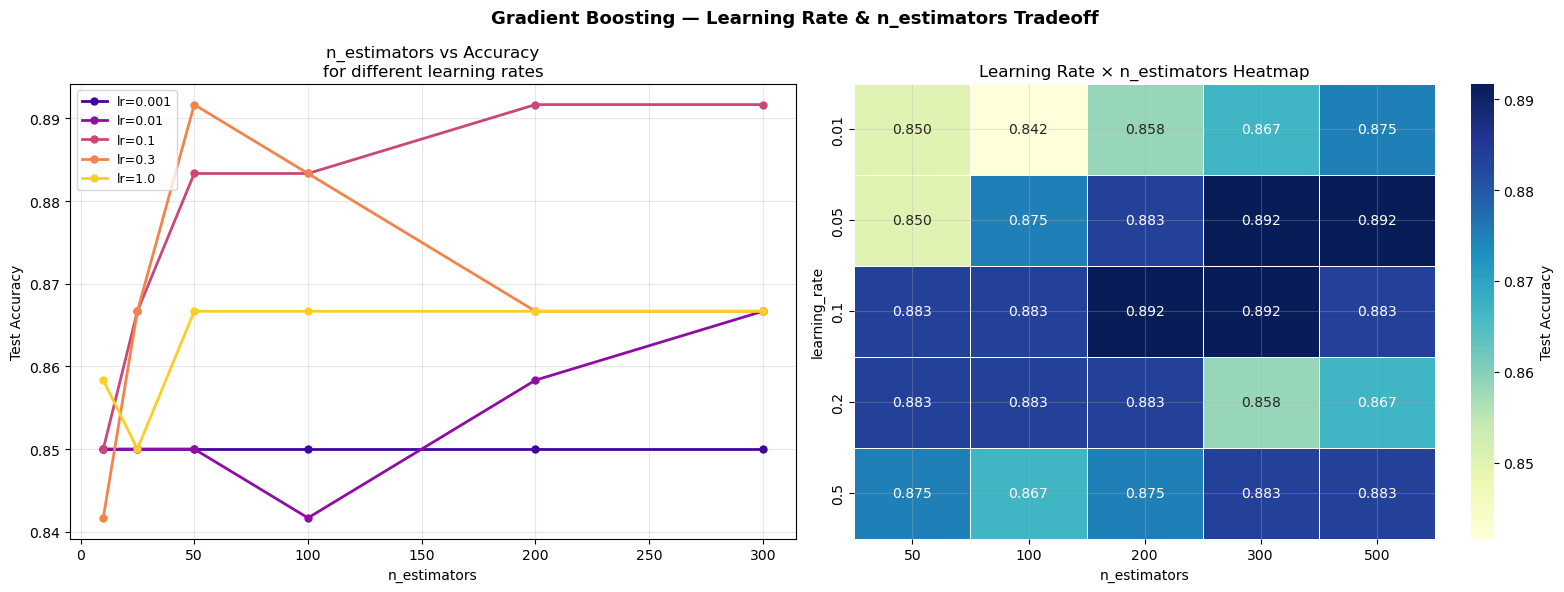

Key rule: smaller learning_rate needs more trees to converge,
but usually generalizes better. Use early stopping to find the sweet spot.


In [4]:
lr_values = [0.001, 0.01, 0.1, 0.3, 1.0]
n_trees   = [10, 25, 50, 100, 200, 300]
colors_lr = plt.cm.plasma(np.linspace(0.1, 0.9, len(lr_values)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: test accuracy vs n_estimators for each learning_rate
for lr, color in zip(lr_values, colors_lr):
    accs = []
    for n in n_trees:
        clf = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr,
            max_depth=3, random_state=42
        )
        clf.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, clf.predict(X_test)))
    axes[0].plot(n_trees, accs, 'o-', color=color, linewidth=2,
                 markersize=5, label=f'lr={lr}')

axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('n_estimators vs Accuracy\nfor different learning rates')
axes[0].legend(fontsize=9)

# Right: tradeoff heatmap
lr_grid = [0.01, 0.05, 0.1, 0.2, 0.5]
n_grid  = [50, 100, 200, 300, 500]
heat    = np.zeros((len(lr_grid), len(n_grid)))

for i, lr in enumerate(lr_grid):
    for j, n in enumerate(n_grid):
        clf = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr,
            max_depth=3, random_state=42
        )
        clf.fit(X_train, y_train)
        heat[i, j] = accuracy_score(y_test, clf.predict(X_test))

sns.heatmap(
    pd.DataFrame(heat, index=lr_grid, columns=n_grid),
    annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, ax=axes[1],
    cbar_kws={'label': 'Test Accuracy'}
)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('learning_rate')
axes[1].set_title('Learning Rate × n_estimators Heatmap')

plt.suptitle('Gradient Boosting — Learning Rate & n_estimators Tradeoff',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key rule: smaller learning_rate needs more trees to converge,')
print('but usually generalizes better. Use early stopping to find the sweet spot.')

## 5. Staged Predictions — Watching the Model Improve

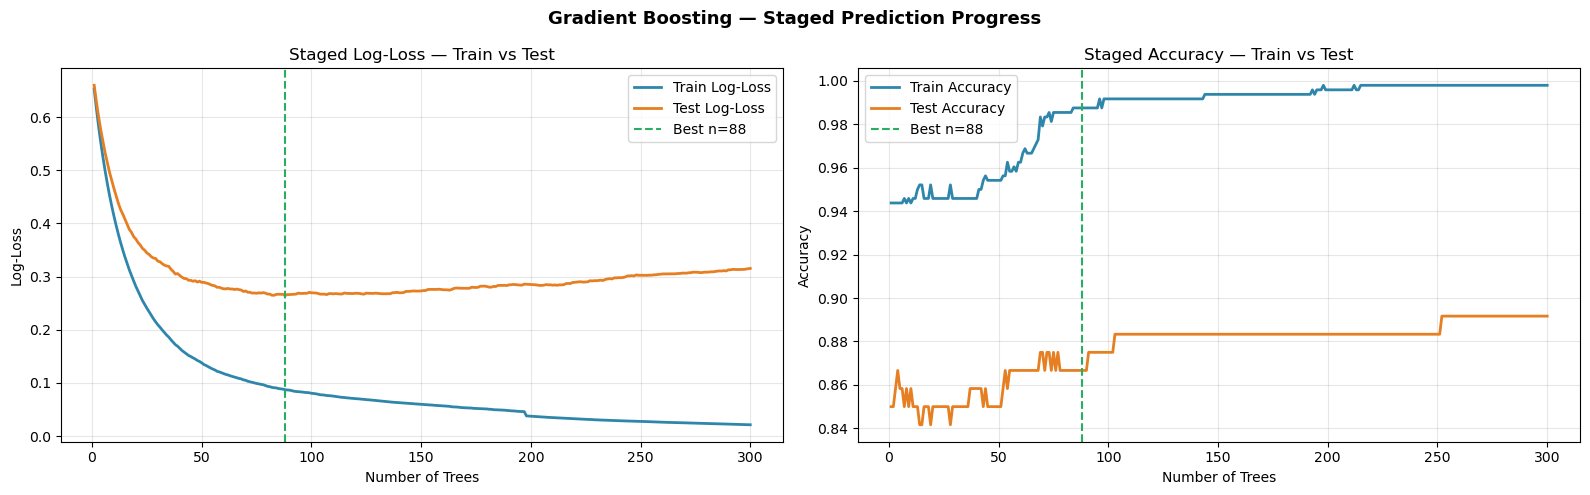

Optimal number of trees (min test log-loss): 88
Test Accuracy at optimal: 0.8667


In [5]:
gb_staged = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, random_state=42
)
gb_staged.fit(X_train, y_train)

train_deviance = []
test_deviance  = []
train_acc_s    = []
test_acc_s     = []

for i, (y_tr_pred, y_te_pred) in enumerate(
    zip(gb_staged.staged_predict_proba(X_train),
        gb_staged.staged_predict_proba(X_test))
):
    # Log-loss (deviance)
    p_tr = np.clip(y_tr_pred[:, 1], 1e-6, 1-1e-6)
    p_te = np.clip(y_te_pred[:, 1], 1e-6, 1-1e-6)
    train_deviance.append(-np.mean(y_train*np.log(p_tr) + (1-y_train)*np.log(1-p_tr)))
    test_deviance.append( -np.mean(y_test *np.log(p_te) + (1-y_test )*np.log(1-p_te)))
    train_acc_s.append(accuracy_score(y_train, y_tr_pred.argmax(axis=1)))
    test_acc_s.append( accuracy_score(y_test,  y_te_pred.argmax(axis=1)))

best_n = np.argmin(test_deviance) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

iters = range(1, 301)
ax1.plot(iters, train_deviance, color=COLORS['primary'],   linewidth=2, label='Train Log-Loss')
ax1.plot(iters, test_deviance,  color=COLORS['secondary'], linewidth=2, label='Test Log-Loss')
ax1.axvline(best_n, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best n={best_n}')
ax1.set_xlabel('Number of Trees'); ax1.set_ylabel('Log-Loss')
ax1.set_title('Staged Log-Loss — Train vs Test')
ax1.legend()

ax2.plot(iters, train_acc_s, color=COLORS['primary'],   linewidth=2, label='Train Accuracy')
ax2.plot(iters, test_acc_s,  color=COLORS['secondary'], linewidth=2, label='Test Accuracy')
ax2.axvline(best_n, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best n={best_n}')
ax2.set_xlabel('Number of Trees'); ax2.set_ylabel('Accuracy')
ax2.set_title('Staged Accuracy — Train vs Test')
ax2.legend()

plt.suptitle('Gradient Boosting — Staged Prediction Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Optimal number of trees (min test log-loss): {best_n}')
print(f'Test Accuracy at optimal: {test_acc_s[best_n-1]:.4f}')

## 6. Feature Importance

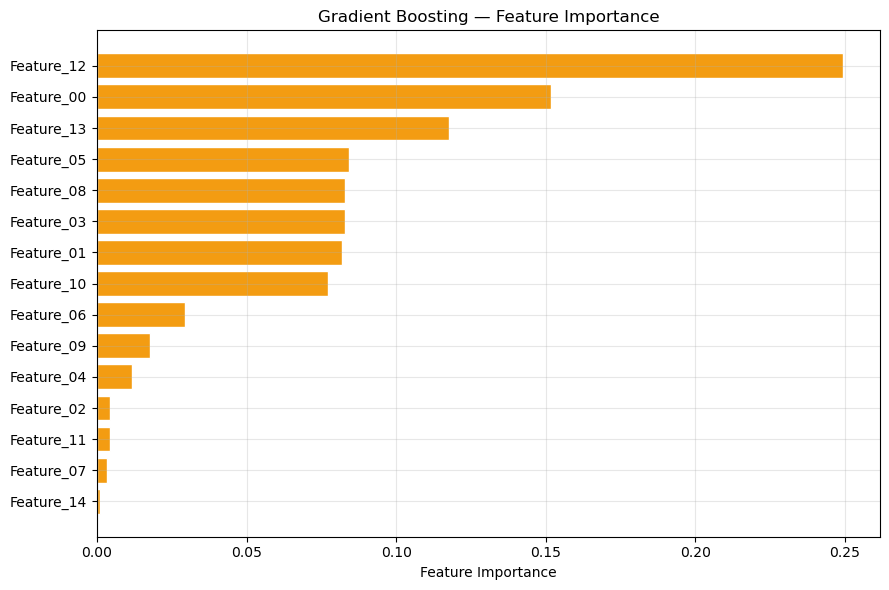

Test Accuracy : 0.9571
Test ROC-AUC  : 0.9853

Top 5 Features:
   Feature  Importance
Feature_12    0.249310
Feature_00    0.151721
Feature_13    0.117796
Feature_05    0.084387
Feature_08    0.082911


In [6]:
np.random.seed(7)
X_imp, y_imp = make_classification(
    n_samples=700, n_features=15, n_informative=8,
    n_redundant=4, random_state=7
)
feat_names = [f'Feature_{i:02d}' for i in range(15)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

gb_imp = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
gb_imp.fit(X_imp_tr, y_imp_tr)

imp_df = pd.DataFrame({
    'Feature':    feat_names,
    'Importance': gb_imp.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'],
         color=COLORS['gb'], edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting — Feature Importance')
plt.tight_layout()
plt.show()

print(f'Test Accuracy : {accuracy_score(y_imp_te, gb_imp.predict(X_imp_te)):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_imp_te, gb_imp.predict_proba(X_imp_te)[:, 1]):.4f}')
print('\nTop 5 Features:')
print(imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 7. Partial Dependence Plots (PDP)

PDPs show the **marginal effect** of one or two features on the predicted outcome, averaging over all other features.

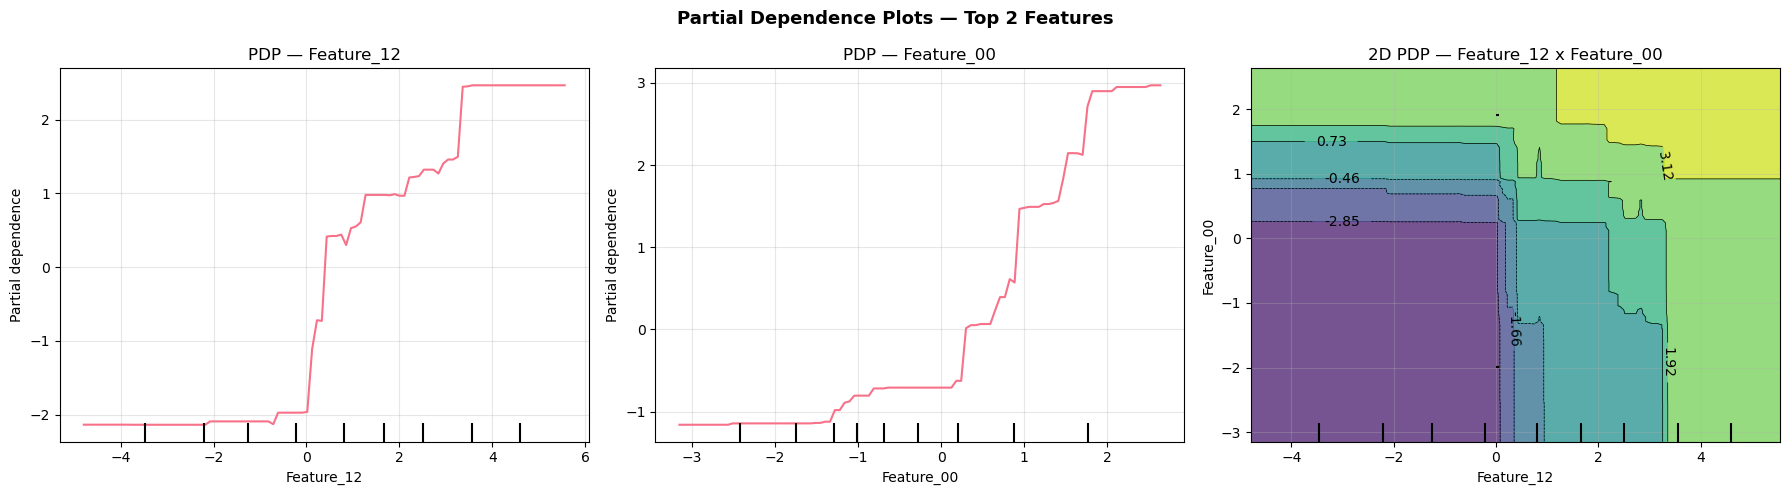

PDP shows how the model prediction changes as one feature varies,
while all other features are averaged out.


In [7]:
top2_idx = imp_df.sort_values('Importance', ascending=False).index[:2].tolist()
top2_names = [feat_names[i] for i in top2_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Individual PDPs for top 2 features
PartialDependenceDisplay.from_estimator(
    gb_imp, X_imp_tr, features=[top2_idx[0]],
    feature_names=feat_names, ax=axes[0]
)
axes[0].set_title(f'PDP — {top2_names[0]}')

PartialDependenceDisplay.from_estimator(
    gb_imp, X_imp_tr, features=[top2_idx[1]],
    feature_names=feat_names, ax=axes[1]
)
axes[1].set_title(f'PDP — {top2_names[1]}')

# 2D interaction PDP
PartialDependenceDisplay.from_estimator(
    gb_imp, X_imp_tr, features=[(top2_idx[0], top2_idx[1])],
    feature_names=feat_names, ax=axes[2], kind='average'
)
axes[2].set_title(f'2D PDP — {top2_names[0]} x {top2_names[1]}')

plt.suptitle('Partial Dependence Plots — Top 2 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('PDP shows how the model prediction changes as one feature varies,')
print('while all other features are averaged out.')

## 8. Gradient Boosting Regressor

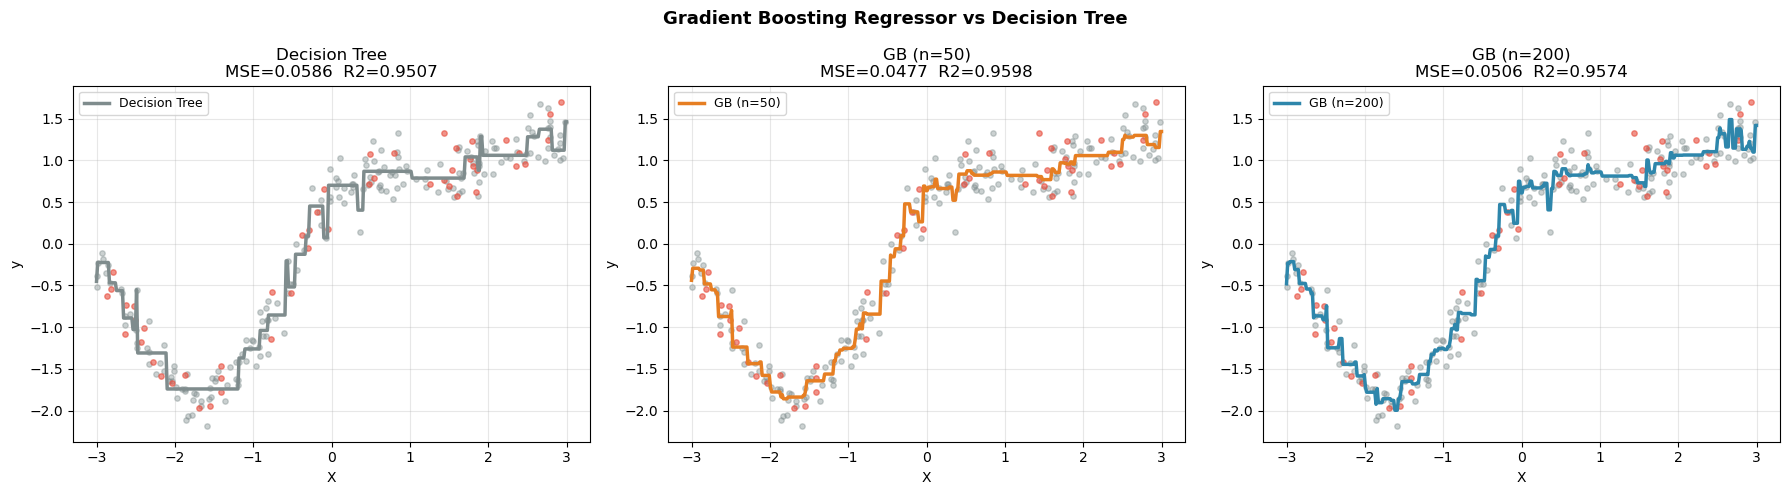

In [8]:
np.random.seed(5)
X_r = np.sort(np.random.uniform(-3, 3, 250)).reshape(-1, 1)
y_r = (np.sin(X_r).ravel() + 0.5*np.cos(2*X_r).ravel()
       + 0.2*X_r.ravel() + np.random.randn(250)*0.2)

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

from sklearn.tree import DecisionTreeRegressor
reg_models = {
    'Decision Tree':   DecisionTreeRegressor(max_depth=5, random_state=42),
    'GB (n=50)':       GradientBoostingRegressor(n_estimators=50,  learning_rate=0.1, max_depth=3, random_state=42),
    'GB (n=200)':      GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
}
plot_colors = [COLORS['neutral'], COLORS['secondary'], COLORS['primary']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model), color in zip(axes, reg_models.items(), plot_colors):
    model.fit(X_r_tr, y_r_tr)
    mse = mean_squared_error(y_r_te, model.predict(X_r_te))
    r2  = r2_score(y_r_te,           model.predict(X_r_te))

    ax.scatter(X_r_tr, y_r_tr, s=15, alpha=0.4, color=COLORS['neutral'])
    ax.scatter(X_r_te, y_r_te, s=15, alpha=0.6, color=COLORS['danger'])
    ax.plot(X_plot, model.predict(X_plot), color=color, linewidth=2.5, label=name)
    ax.set_title(f'{name}\nMSE={mse:.4f}  R2={r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=9)

plt.suptitle('Gradient Boosting Regressor vs Decision Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Stochastic Gradient Boosting — subsample Parameter

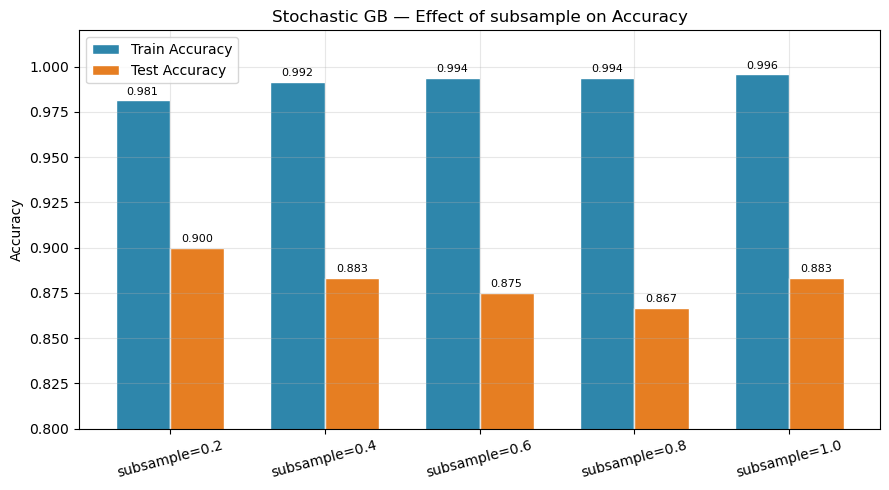

subsample < 1.0 -> Stochastic Gradient Boosting
Each tree is trained on a random fraction of the data.
This introduces randomness (like RF) -> reduces overfitting + faster training.


In [9]:
subsamples   = [0.2, 0.4, 0.6, 0.8, 1.0]
train_accs_s = []
test_accs_s  = []

for ss in subsamples:
    clf = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, subsample=ss, random_state=42
    )
    clf.fit(X_train, y_train)
    train_accs_s.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs_s.append( accuracy_score(y_test,  clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(subsamples))
width = 0.35
ax.bar(x_pos - width/2, train_accs_s, width, label='Train Accuracy',
       color=COLORS['primary'], edgecolor='white')
ax.bar(x_pos + width/2, test_accs_s,  width, label='Test Accuracy',
       color=COLORS['secondary'], edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'subsample={s}' for s in subsamples], rotation=15)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.02)
ax.set_title('Stochastic GB — Effect of subsample on Accuracy')
ax.legend()

for i, (tr, te) in enumerate(zip(train_accs_s, test_accs_s)):
    ax.text(i - width/2, tr + 0.003, f'{tr:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, te + 0.003, f'{te:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('subsample < 1.0 -> Stochastic Gradient Boosting')
print('Each tree is trained on a random fraction of the data.')
print('This introduces randomness (like RF) -> reduces overfitting + faster training.')

## 10. Hyperparameter Tuning — GridSearchCV

In [10]:
param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [2, 3, 5],
    'subsample':     [0.7, 1.0],
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_gb   = grid.best_estimator_
best_pred = best_gb.predict(X_test)
best_prob = best_gb.predict_proba(X_test)[:, 1]

print(f'Best Params   : {grid.best_params_}')
print(f'Best CV AUC   : {grid.best_score_:.4f}')
print(f'Test Accuracy : {accuracy_score(y_test, best_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, best_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_test, best_pred):.4f}')

Best Params   : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best CV AUC   : 0.9805
Test Accuracy : 0.8583
Test ROC-AUC  : 0.9665
Test F1 Score : 0.8595


## 11. Real-World Offline-Safe Dataset — Employee Attrition

In [11]:
np.random.seed(88)
n_emp = 1000

Age             = np.random.randint(22, 60, n_emp).astype(float)
MonthlyIncome   = np.random.uniform(2000, 20000, n_emp)
YearsAtCompany  = np.random.uniform(0, 20, n_emp)
JobSatisfaction = np.random.randint(1, 5, n_emp).astype(float)
WorkLifeBalance = np.random.randint(1, 5, n_emp).astype(float)
OverTime        = np.random.randint(0, 2, n_emp).astype(float)
DistFromHome    = np.random.randint(1, 30, n_emp).astype(float)
NumCompWorked   = np.random.randint(1, 10, n_emp).astype(float)
TrainingTimes   = np.random.randint(0, 7, n_emp).astype(float)
PerformRating   = np.random.randint(1, 5, n_emp).astype(float)

feat_names_emp = ['Age','MonthlyIncome','YearsAtCompany','JobSatisfaction',
                  'WorkLifeBalance','OverTime','DistFromHome',
                  'NumCompWorked','TrainingTimes','PerformRating']

X_emp = np.column_stack([Age, MonthlyIncome, YearsAtCompany, JobSatisfaction,
                          WorkLifeBalance, OverTime, DistFromHome,
                          NumCompWorked, TrainingTimes, PerformRating])

log_odds = (1 - 0.03*Age - 0.00005*MonthlyIncome - 0.05*YearsAtCompany
            - 0.3*JobSatisfaction - 0.25*WorkLifeBalance + 0.8*OverTime
            + 0.03*DistFromHome + 0.1*NumCompWorked - 0.05*TrainingTimes)
prob_att  = 1 / (1 + np.exp(-log_odds))
y_emp     = (prob_att > np.random.uniform(0, 1, n_emp)).astype(int)

print(f'Dataset shape : {X_emp.shape}')
print(f'Class balance : {np.bincount(y_emp)}  (0=Stayed, 1=Left)')

X_emp_tr, X_emp_te, y_emp_tr, y_emp_te = train_test_split(
    X_emp, y_emp, test_size=0.2, random_state=42, stratify=y_emp
)

gb_emp = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gb_emp.fit(X_emp_tr, y_emp_tr)

emp_pred = gb_emp.predict(X_emp_te)
emp_prob = gb_emp.predict_proba(X_emp_te)[:, 1]

print(f'\nTest Accuracy : {accuracy_score(y_emp_te, emp_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_emp_te, emp_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_emp_te, emp_pred):.4f}')

cv_scores = cross_val_score(
    gb_emp, X_emp, y_emp,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Dataset shape : (1000, 10)
Class balance : [777 223]  (0=Stayed, 1=Left)

Test Accuracy : 0.8050
Test ROC-AUC  : 0.7125
Test F1 Score : 0.4000
5-Fold CV ROC-AUC : 0.6621 +/- 0.0184


## 12. Full Model Evaluation

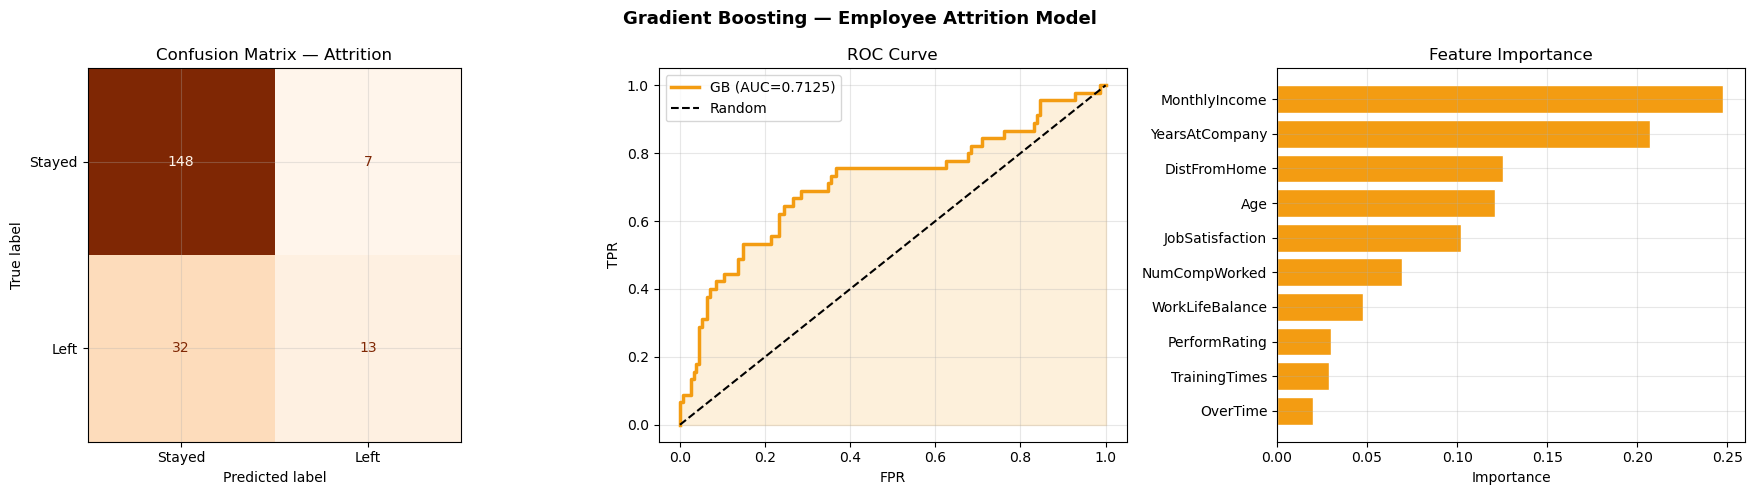

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.95      0.88       155
        Left       0.65      0.29      0.40        45

    accuracy                           0.81       200
   macro avg       0.74      0.62      0.64       200
weighted avg       0.78      0.81      0.77       200



In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_emp = confusion_matrix(y_emp_te, emp_pred)
ConfusionMatrixDisplay(cm_emp, display_labels=['Stayed','Left']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges'
)
axes[0].set_title('Confusion Matrix — Attrition')

# ROC curve
fpr_e, tpr_e, _ = roc_curve(y_emp_te, emp_prob)
auc_e = roc_auc_score(y_emp_te, emp_prob)
axes[1].plot(fpr_e, tpr_e, color=COLORS['gb'], linewidth=2.5,
             label=f'GB (AUC={auc_e:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr_e, tpr_e, alpha=0.15, color=COLORS['gb'])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature importance
imp_emp = pd.DataFrame({
    'Feature':    feat_names_emp,
    'Importance': gb_emp.feature_importances_
}).sort_values('Importance', ascending=True)

axes[2].barh(imp_emp['Feature'], imp_emp['Importance'],
             color=COLORS['gb'], edgecolor='white')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance')

plt.suptitle('Gradient Boosting — Employee Attrition Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_emp_te, emp_pred, target_names=['Stayed','Left']))

## 13. DT vs RF vs Gradient Boosting — Head-to-Head

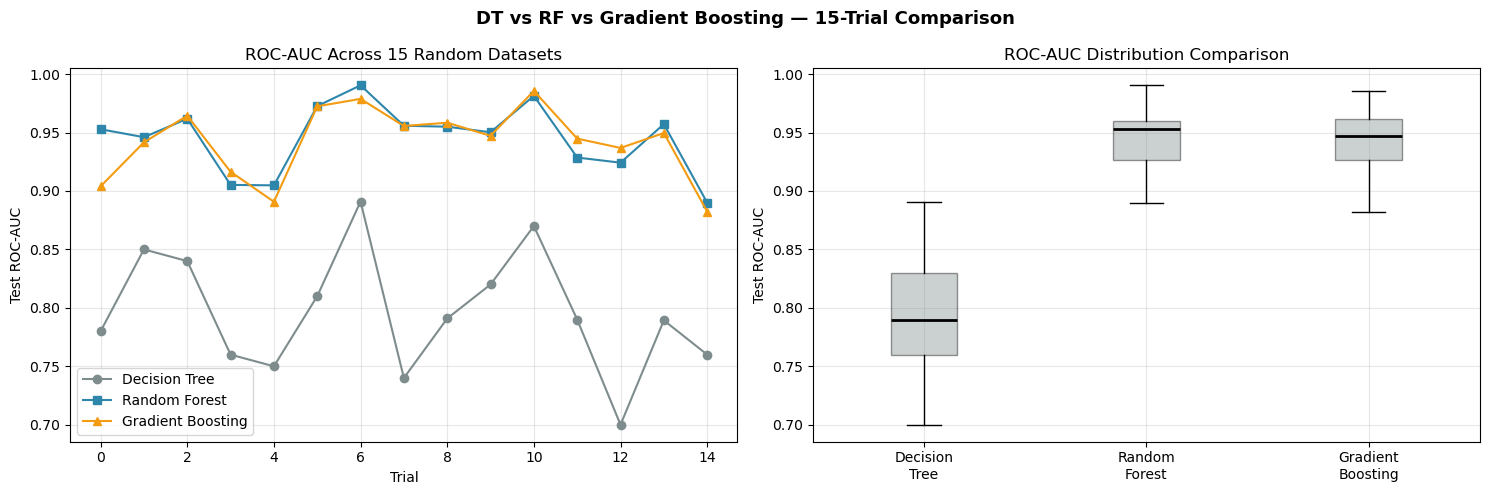

Decision Tree      mean=0.7961  std=0.0500
Random Forest      mean=0.9451  std=0.0281
Gradient Boosting  mean=0.9419  std=0.0300


In [13]:
n_trials = 15
dt_scores  = []
rf_scores  = []
gb_scores  = []

for seed in range(n_trials):
    X_t, y_t = make_classification(
        n_samples=500, n_features=12, n_informative=7,
        n_redundant=3, random_state=seed
    )
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=seed, stratify=y_t
    )
    dt = DecisionTreeClassifier(random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    gb_c = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=seed)
    for m in [dt, rf, gb_c]:
        m.fit(X_tr, y_tr)
    dt_scores.append(roc_auc_score(y_te, dt.predict_proba(X_te)[:, 1]))
    rf_scores.append(roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1]))
    gb_scores.append(roc_auc_score(y_te, gb_c.predict_proba(X_te)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(dt_scores, 'o-', color=COLORS['neutral'],   linewidth=1.5, label='Decision Tree')
axes[0].plot(rf_scores, 's-', color=COLORS['primary'],   linewidth=1.5, label='Random Forest')
axes[0].plot(gb_scores, '^-', color=COLORS['gb'],        linewidth=1.5, label='Gradient Boosting')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Test ROC-AUC')
axes[0].set_title('ROC-AUC Across 15 Random Datasets')
axes[0].legend()

axes[1].boxplot([dt_scores, rf_scores, gb_scores],
                labels=['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting'],
                patch_artist=True,
                boxprops=dict(facecolor=COLORS['neutral'], alpha=0.4),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('ROC-AUC Distribution Comparison')

plt.suptitle('DT vs RF vs Gradient Boosting — 15-Trial Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Decision Tree      mean={np.mean(dt_scores):.4f}  std={np.std(dt_scores):.4f}')
print(f'Random Forest      mean={np.mean(rf_scores):.4f}  std={np.std(rf_scores):.4f}')
print(f'Gradient Boosting  mean={np.mean(gb_scores):.4f}  std={np.std(gb_scores):.4f}')

## 14. Final Summary & Key Takeaways

In [14]:
print('=' * 68)
print('          GRADIENT BOOSTING - KEY TAKEAWAYS')
print('=' * 68)

takeaways = [
    ('Core idea',        'Sequentially fit trees to residuals of current ensemble'),
    ('vs Random Forest', 'RF: parallel trees averaged; GB: sequential trees correcting errors'),
    ('learning_rate',    'Shrinks each tree contribution; smaller = better but needs more trees'),
    ('n_estimators',     'Number of boosting rounds; tune with staged_predict or early stopping'),
    ('max_depth',        'Keep shallow (2-5); deep trees overfit residuals quickly'),
    ('subsample',        'Stochastic GB: fraction < 1.0 reduces variance, speeds training'),
    ('Feature scaling',  'NOT required — tree-based splits use raw thresholds'),
    ('Feature importance','Built-in via impurity reduction across all trees'),
    ('PDP',              'Partial Dependence Plots reveal marginal effect of each feature'),
    ('Staged predict',   'Use staged_predict to find optimal n_estimators post-training'),
    ('Weakness',         'Slower to train than RF; harder to tune; sensitive to outliers'),
    ('Next step',        'XGBoost / LightGBM / CatBoost: faster, regularized, more scalable'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<20}  ->  {detail}')

print('=' * 68)

          GRADIENT BOOSTING - KEY TAKEAWAYS
  OK  Core idea             ->  Sequentially fit trees to residuals of current ensemble
  OK  vs Random Forest      ->  RF: parallel trees averaged; GB: sequential trees correcting errors
  OK  learning_rate         ->  Shrinks each tree contribution; smaller = better but needs more trees
  OK  n_estimators          ->  Number of boosting rounds; tune with staged_predict or early stopping
  OK  max_depth             ->  Keep shallow (2-5); deep trees overfit residuals quickly
  OK  subsample             ->  Stochastic GB: fraction < 1.0 reduces variance, speeds training
  OK  Feature scaling       ->  NOT required — tree-based splits use raw thresholds
  OK  Feature importance    ->  Built-in via impurity reduction across all trees
  OK  PDP                   ->  Partial Dependence Plots reveal marginal effect of each feature
  OK  Staged predict        ->  Use staged_predict to find optimal n_estimators post-training
  OK  Weakness          

---
## Practice Exercises

1. **Early stopping** — use `n_iter_no_change` and `validation_fraction` parameters to auto-stop training.
2. **Loss functions** — compare `loss='log_loss'` vs `'exponential'` (AdaBoost-style) on the same dataset.
3. **Individual tree inspection** — access `gb.estimators_[i][0]` and plot a single weak learner.
4. **Compare GB vs XGBoost** — install xgboost and benchmark accuracy and training time.
5. **Tune with RandomizedSearchCV** — use a wider grid of hyperparameters than GridSearchCV allows.
6. **Plot learning curves** — use `sklearn.model_selection.learning_curve` to see if more data helps.

---
*Notebook created for the ML Repository — Gradient Boosting module.*